<a href="https://colab.research.google.com/github/corrielynnyuill-debug/assignment5-cly/blob/main/Lesson_5_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment - EDA using Pandas**

***Instructions***
- Clone a copy of the assignment notebook in Google Colab.
- **Complete the tasks by filling in the code where indicated by TODO comments. Put each task in a new cell.**
- Run each cell to ensure your code works correctly.
- Pay attention to the output of each cell and interpret the results.
- For visualisation tasks, make sure to label axes, add titles, and choose appropriate colour schemes.
- After completing all tasks, review your findings and include notes of your insights gained from the EDA process as markdown notes for assessments.


In [25]:
# Titanic Dataset Exploratory Data Analysis

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Load the Titanic dataset
# TODO: Load the Titanic dataset from the following URL
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
df = pd.read_csv(url)

# Task 2: Inspect the data
# TODO: Display the first 5 rows of the dataset
print(df.head())
print('-'*80)

# TODO: Display the last 5 rows of the dataset
print(df.tail())
print('-'*80)

# TODO: Display the data types of each column
print(df.dtypes)
print('-'*80)

# TODO: Display summary statistics of the numerical columns
print(df.describe())


   Survived  Pclass                                               Name  \
0         0       3                             Mr. Owen Harris Braund   
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2         1       3                              Miss. Laina Heikkinen   
3         1       1        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4         0       3                            Mr. William Henry Allen   

      Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare  
0    male  22.0                        1                        0   7.2500  
1  female  38.0                        1                        0  71.2833  
2  female  26.0                        0                        0   7.9250  
3  female  35.0                        1                        0  53.1000  
4    male  35.0                        0                        0   8.0500  
--------------------------------------------------------------------------------
     Survive

In [26]:
# Task 3: Clean and preprocess the data

# TODO: Create a new categorical feature 'PclassCategory' from 'Pclass'
pclass_mapping = {1: 'First', 2: 'Second', 3: 'Third'}
df['PclassCategory'] = df['Pclass'].map(pclass_mapping).astype('category')

# TODO: Create a new categorical feature 'CabinCategory' from 'Cabin'
df["CabinCategory"] = 'Unknown'
df["CabinCategory"] = df["CabinCategory"].astype("category")


# TODO: Handle missing values in the 'Age' column (use mean age)
print("Null Values Before:",df["Age"].isnull().sum())
df["Age"].fillna(df["Age"].mean())

print("Null Values After:",df["Age"].isnull().sum())

# TODO: Handle missing values in the 'Embarked' column (use mode
# print("Null Values Before:",df["Embarked"].isnull().sum())
# df["Embarked"].fillna(df["Embarked"].mode())
# print("Null Values After:",df["Embarked"].isnull().sum())

# TODO: Create a 'Family' feature by combining 'SibSp' and 'Parch'
df["Family"] = (
    df["Siblings/Spouses Aboard"] +
    df["Parents/Children Aboard"] +
    1
)


Null Values Before: 0
Null Values After: 0


In [27]:
# Task 4: Identify specific data points

# TODO: Find passengers with the highest fare
highest_fare = df["Fare"].max
highest_fare_passengers = df[df["Fare"] == highest_fare]
print("Highest Paying Passengers:\n", highest_fare_passengers)

# TODO: Find passengers with the largest family size
largest_family_size = df["Family"].max()
largest_family_passengers = df[df["Family"] == largest_family_size]
print("Largest Family:\n", largest_family_passengers)



Highest Paying Passengers:
 Empty DataFrame
Columns: [Survived, Pclass, Name, Sex, Age, Siblings/Spouses Aboard, Parents/Children Aboard, Fare, PclassCategory, CabinCategory, Family]
Index: []
Largest Family:
      Survived  Pclass                         Name     Sex   Age  \
158         0       3    Master. Thomas Henry Sage    male   5.0   
179         0       3  Miss. Constance Gladys Sage  female   8.0   
200         0       3           Mr. Frederick Sage    male  17.0   
322         0       3      Mr. George John Jr Sage    male  20.0   
788         0       3       Miss. Stella Anna Sage  female  21.0   
842         0       3      Mr. Douglas Bullen Sage    male  18.0   
859         0       3     Miss. Dorothy Edith Sage  female  14.0   

     Siblings/Spouses Aboard  Parents/Children Aboard   Fare PclassCategory  \
158                        8                        2  69.55          Third   
179                        8                        2  69.55          Third   
200     

In [28]:
# Task 5: Demonstrate Pandas Series and DataFrame functionalities

# TODO: Create a Pandas Series of passenger names
name_series = df["Name"]
print(name_series.head())
print('-'*80)

# TODO: Create a DataFrame of passenger names and ages
name_age_df = df[["Name", "Age"]]
print(name_age_df.head())
print('-'*80)

# TODO: Slice the DataFrame to show only passengers older than 50
old_passengers = df[df["Age"] > 50]
print(old_passengers.head())



0                               Mr. Owen Harris Braund
1    Mrs. John Bradley (Florence Briggs Thayer) Cum...
2                                Miss. Laina Heikkinen
3          Mrs. Jacques Heath (Lily May Peel) Futrelle
4                              Mr. William Henry Allen
Name: Name, dtype: object
--------------------------------------------------------------------------------
                                                Name   Age
0                             Mr. Owen Harris Braund  22.0
1  Mrs. John Bradley (Florence Briggs Thayer) Cum...  38.0
2                              Miss. Laina Heikkinen  26.0
3        Mrs. Jacques Heath (Lily May Peel) Futrelle  35.0
4                            Mr. William Henry Allen  35.0
--------------------------------------------------------------------------------
    Survived  Pclass                            Name     Sex   Age  \
6          0       1          Mr. Timothy J McCarthy    male  54.0   
11         1       1         Miss. Elizabet

In [29]:
# Task 6: Introduce multi-indexing

# TODO: Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
multi_index_df = (
    df.groupby(["Sex", "Pclass"])["Survived"]
    .mean()
    .to_frame(name="SurvivalRate")
)
print(multi_index_df)



               SurvivalRate
Sex    Pclass              
female 1           0.968085
       2           0.921053
       3           0.500000
male   1           0.368852
       2           0.157407
       3           0.137026


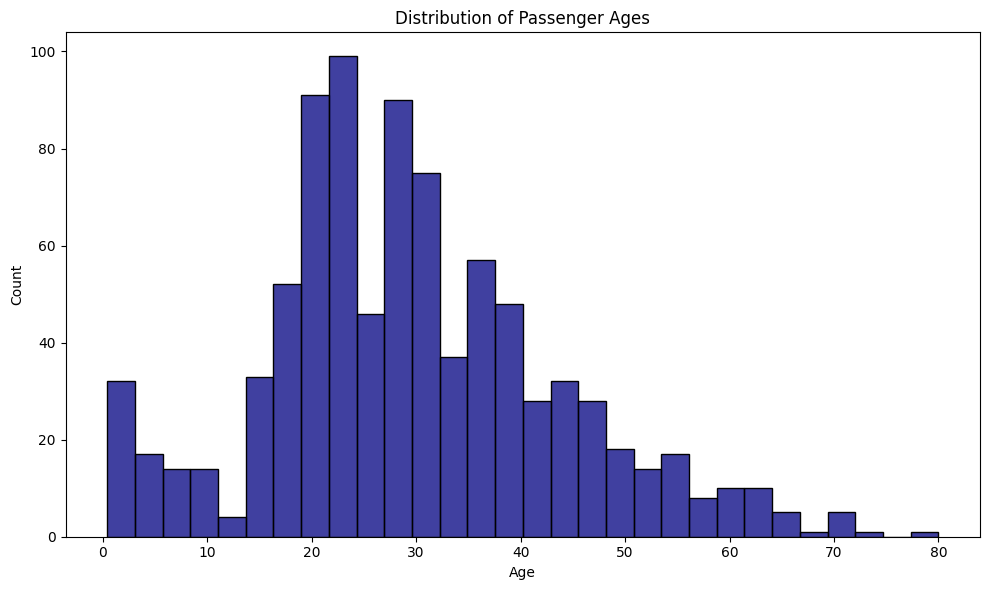

/tmp/ipykernel_11778/3140231463.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=survival_by_class, x="Pclass", y="Survived", palette="viridis")


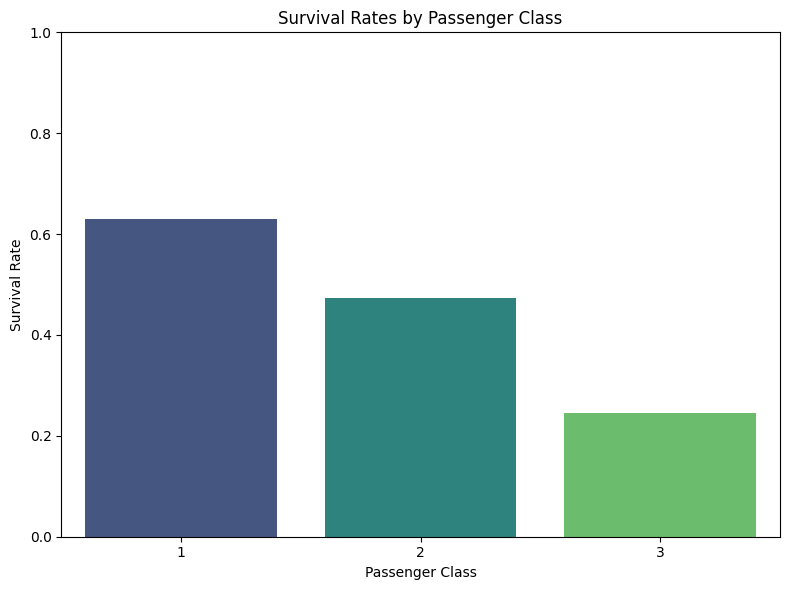

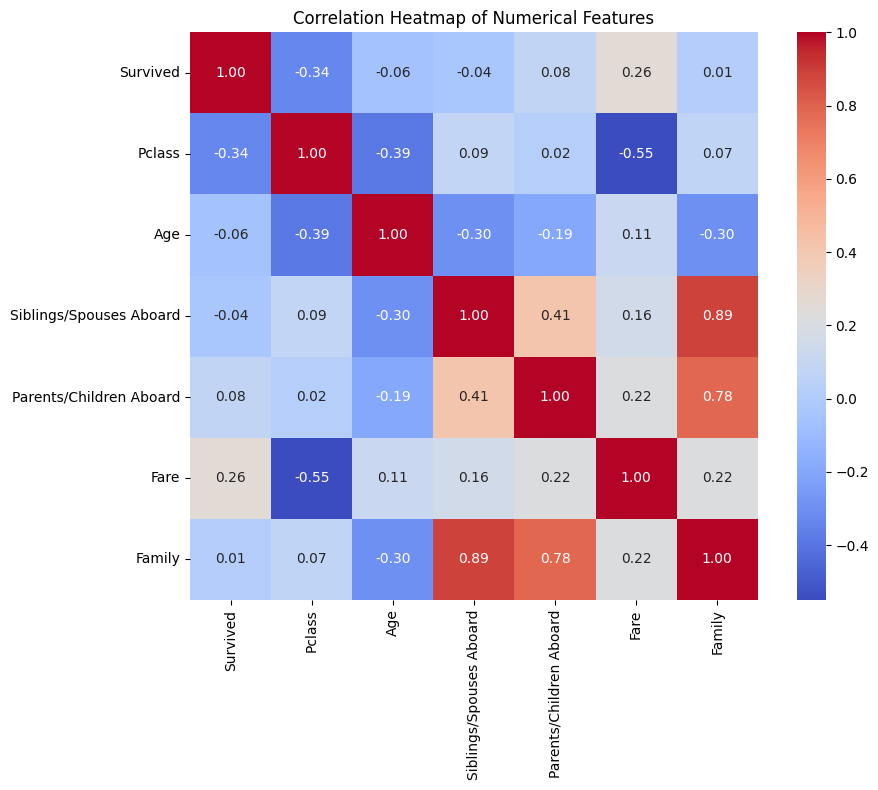

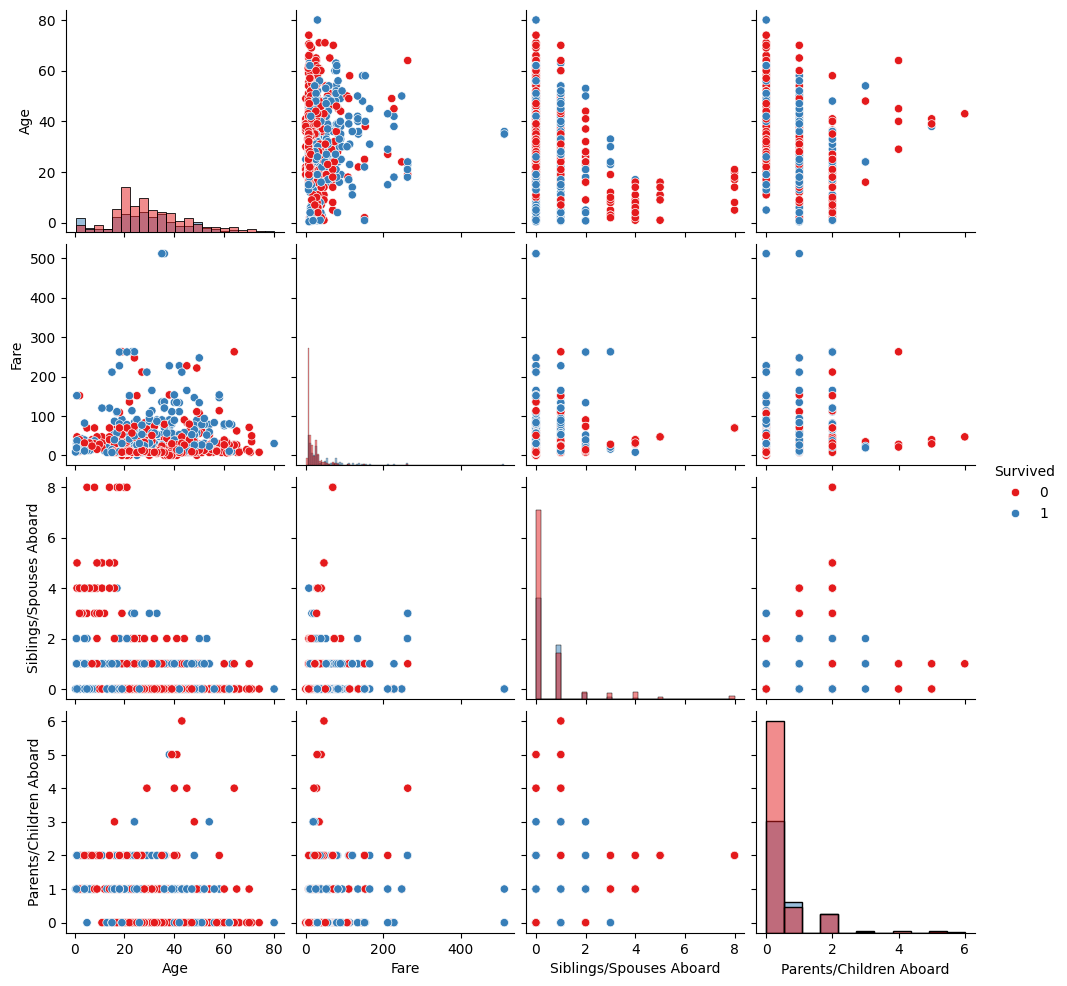

In [30]:
from numpy._core import numeric
# Task 7: Visualizations

# TODO: Create a histogram of passenger ages
plt.figure(figsize=(10, 6))
sns.histplot(df["Age"], bins=30, kde=False, color="navy")
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# TODO: Create a bar plot of survival rates by passenger class
survival_by_class = df.groupby("Pclass")["Survived"].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=survival_by_class, x="Pclass", y="Survived", palette="viridis")
plt.title("Survival Rates by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# TODO: Create a heatmap of correlation between numerical features
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

# TODO: Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
sns.pairplot(
    df[["Age", "Fare", "Siblings/Spouses Aboard", "Parents/Children Aboard", "Survived"]],
    hue="Survived",
    diag_kind="hist",
    palette="Set1",
)
plt.show()

In [31]:
# Task 8: Analyze survival rates

# TODO: Calculate and display survival rates by sex
survival_by_sex = df.groupby("Sex")["Survived"].mean()
print("Survival Rates by Sex:")
print(survival_by_sex)

# TODO: Calculate and display survival rates by passenger class
survival_by_class = df.groupby("Pclass")["Survived"].mean()
print("\nSurvival Rates by Passenger Class:")
print(survival_by_class)


Survival Rates by Sex:
Sex
female    0.742038
male      0.190227
Name: Survived, dtype: float64

Survival Rates by Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.244353
Name: Survived, dtype: float64


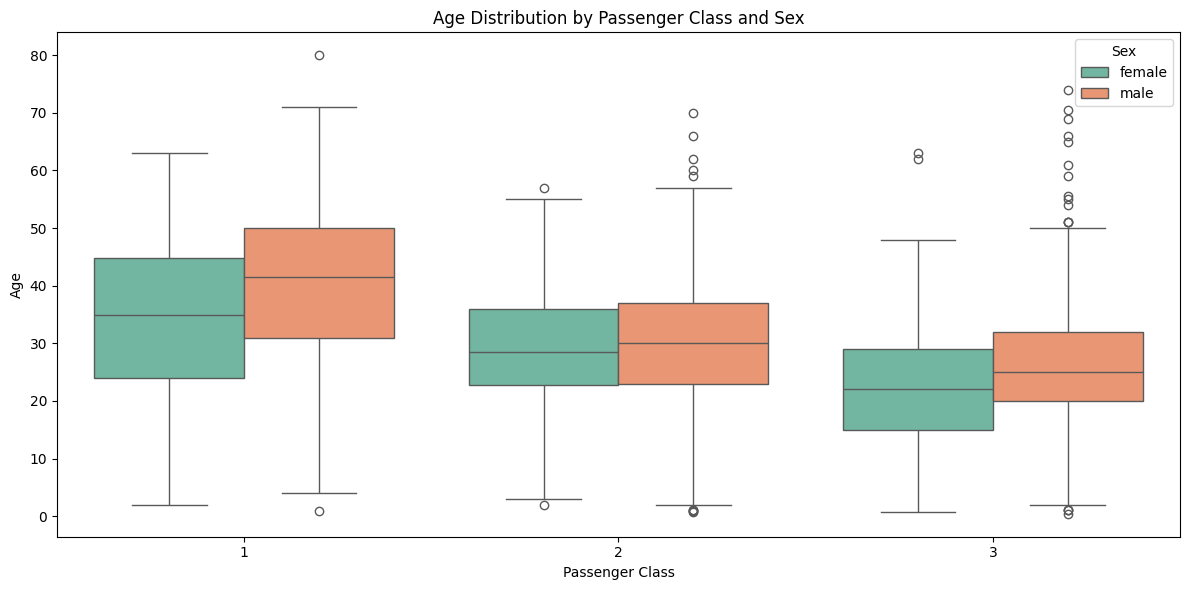

In [32]:
# Task 9: Analyze age distribution

# TODO: Create a box plot of age distribution by passenger class and sex
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Pclass", y="Age", hue="Sex", palette="Set2")
plt.title("Age Distribution by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


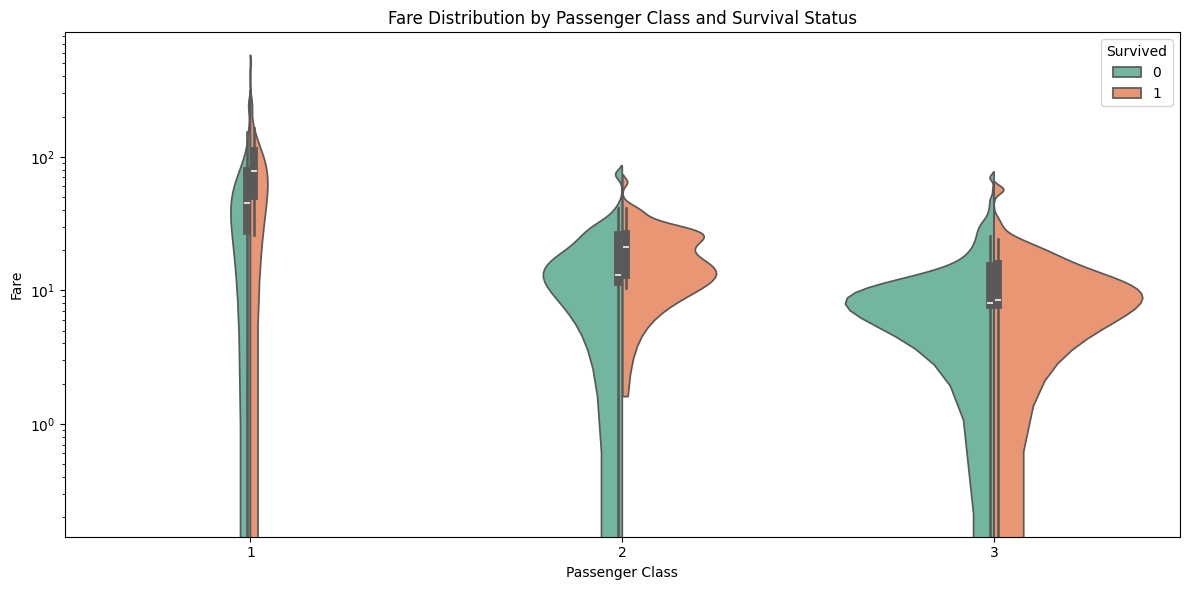

EDA tasks completed.


In [33]:
# Task 10: Analyze fare distribution

# TODO: Create a violin plot of fare distribution by passenger class and survival status
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df,
    x="Pclass",
    y="Fare",
    hue="Survived",
    split=True,
    palette="Set2"
)
plt.title("Fare Distribution by Passenger Class and Survival Status")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.yscale("log")
plt.tight_layout()
plt.show()

print("EDA tasks completed.")